In [1]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
from collections import Counter

In [2]:
import torchvision
from torchvision.datasets import VOCDetection

# Скачиваем train и val (это займёт ~2 ГБ)
voc_train = VOCDetection(root='./data', year='2012', image_set='train', download=False)
voc_val   = VOCDetection(root='./data', year='2012', image_set='val', download=False)

print("Готово! Датасет распакован в ./data/VOCdevkit/VOC2012")

Готово! Датасет распакован в ./data/VOCdevkit/VOC2012


In [3]:
VOC_ROOT = './data/VOCdevkit/VOC2012'
JPEG_DIR = os.path.join(VOC_ROOT, 'JPEGImages')
ANNOT_DIR = os.path.join(VOC_ROOT, 'Annotations')
IMSETS_DIR = os.path.join(VOC_ROOT, 'ImageSets', 'Main')

In [4]:
def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    size = root.find('size')
    width = int(float(size.find('width').text))
    height = int(float(size.find('height').text))
    
    objects = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(float(bbox.find('xmin').text))
        ymin = int(float(bbox.find('ymin').text))
        xmax = int(float(bbox.find('xmax').text))
        ymax = int(float(bbox.find('ymax').text))
        difficult = obj.find('difficult')
        difficult = int(float(difficult.text)) if difficult is not None else 0
        objects.append({
            'name': name,
            'bbox': [xmin, ymin, xmax, ymax],
            'difficult': difficult
        })
    return {'width': width, 'height': height, 'objects': objects}

In [5]:
import xml.etree.ElementTree as ET

class_counter = Counter()
object_counts = []
areas = []
bad_files = []

for xml_file in os.listdir(ANNOT_DIR):
    if not xml_file.endswith('.xml'):
        continue
    try:
        ann = parse_annotation(os.path.join(ANNOT_DIR, xml_file))
    except Exception as e:
        bad_files.append((xml_file, str(e)))
        continue
    
    object_counts.append(len(ann['objects']))
    for obj in ann['objects']:
        class_counter[obj['name']] += 1
        xmin, ymin, xmax, ymax = obj['bbox']
        areas.append((xmax - xmin) * (ymax - ymin))

print(f"Обработано изображений: {len(object_counts)}")
print(f"Битых файлов: {len(bad_files)}")
if bad_files:
    for f, err in bad_files[:5]:
        print(" ", f, "->", err)

Обработано изображений: 17125
Битых файлов: 0


In [6]:
def show_image_with_boxes(img_id, ax=None):
    img_path = os.path.join(JPEG_DIR, img_id + '.jpg')
    xml_path = os.path.join(ANNOT_DIR, img_id + '.xml')
    
    img = Image.open(img_path).convert('RGB')
    ann = parse_annotation(xml_path)
    
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(12, 8))
    
    ax.imshow(img)
    for obj in ann['objects']:
        xmin, ymin, xmax, ymax = obj['bbox']
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            xmin, max(ymin - 5, 0), obj['name'],
            color='lime', fontsize=10, weight='bold',
            bbox=dict(facecolor='black', alpha=0.6, pad=1)
        )
    ax.axis('off')
    return ax

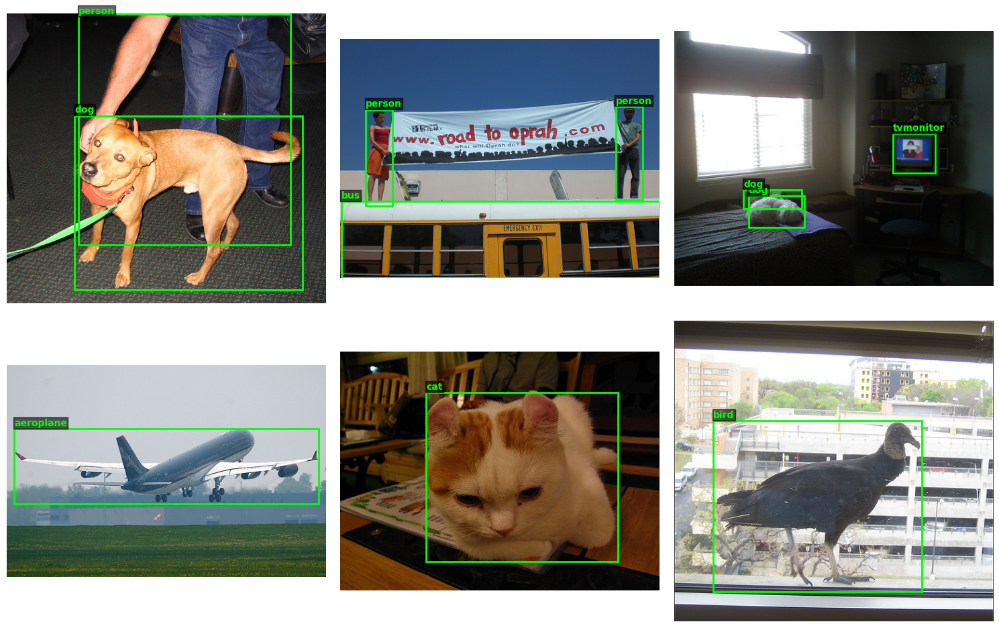

In [7]:
all_ids = [os.path.splitext(f)[0] for f in os.listdir(ANNOT_DIR) if f.endswith('.xml')]
random.seed(42)
sample_ids = random.sample(all_ids, 6)

def show_grid(ids, cols=3, figsize=(15, 10)):
    rows = (len(ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows * cols > 1 else [axes]
    
    for ax, img_id in zip(axes, ids):
        show_image_with_boxes(img_id, ax=ax)
    
    for ax in axes[len(ids):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

show_grid(sample_ids, cols=3)

In [8]:
class_counter = Counter()
object_counts = []
areas = []

for xml_file in os.listdir(ANNOT_DIR):
    if not xml_file.endswith('.xml'):
        continue
    ann = parse_annotation(os.path.join(ANNOT_DIR, xml_file))
    object_counts.append(len(ann['objects']))
    for obj in ann['objects']:
        class_counter[obj['name']] += 1
        xmin, ymin, xmax, ymax = obj['bbox']
        area = (xmax - xmin) * (ymax - ymin)
        areas.append(area)

print("Всего изображений с аннотациями:", len(object_counts))
print("Классы и количество объектов:")
for cls, cnt in class_counter.most_common():
    print(f"  {cls}: {cnt}")

print(f"\nСреднее число объектов на изображение: {sum(object_counts)/len(object_counts):.2f}")
print(f"Максимум объектов на изображение: {max(object_counts)}")
print(f"Минимум объектов на изображение: {min(object_counts)}")

Всего изображений с аннотациями: 17125
Классы и количество объектов:
  person: 17401
  chair: 3056
  car: 2492
  dog: 1598
  bottle: 1561
  cat: 1277
  bird: 1271
  pottedplant: 1202
  sheep: 1084
  boat: 1059
  aeroplane: 1002
  tvmonitor: 893
  sofa: 841
  bicycle: 837
  horse: 803
  motorbike: 801
  diningtable: 800
  cow: 771
  train: 704
  bus: 685

Среднее число объектов на изображение: 2.34
Максимум объектов на изображение: 56
Минимум объектов на изображение: 1


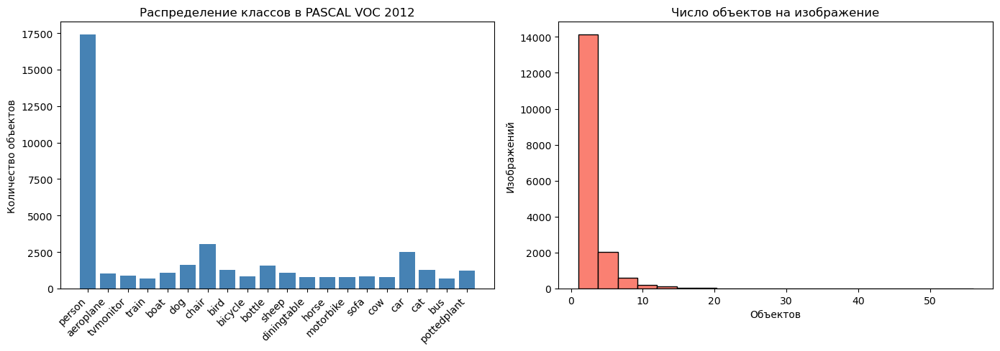

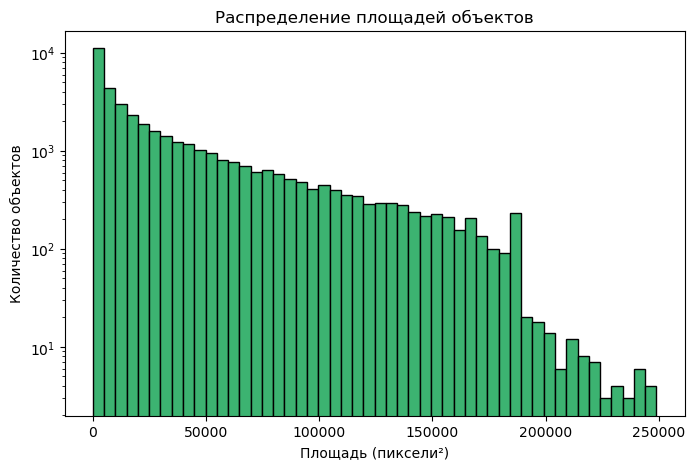

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение классов
axes[0].bar(class_counter.keys(), class_counter.values(), color='steelblue')
axes[0].set_title('Распределение классов в PASCAL VOC 2012')
axes[0].set_ylabel('Количество объектов')
axes[0].tick_params(axis='x', rotation=45)
plt.setp(axes[0].get_xticklabels(), ha='right')   # выравнивание здесь

# Число объектов на изображение
axes[1].hist(object_counts, bins=20, edgecolor='black', color='salmon')
axes[1].set_title('Число объектов на изображение')
axes[1].set_xlabel('Объектов')
axes[1].set_ylabel('Изображений')

plt.tight_layout()
plt.show()

# Распределение площадей объектов
plt.figure(figsize=(8, 5))
plt.hist(areas, bins=50, edgecolor='black', color='mediumseagreen')
plt.title('Распределение площадей объектов')
plt.xlabel('Площадь (пиксели²)')
plt.ylabel('Количество объектов')
plt.yscale('log')
plt.show()

In [10]:
for split in ['train', 'val', 'trainval']:
    split_file = os.path.join(IMSETS_DIR, split + '.txt')
    if os.path.exists(split_file):
        with open(split_file) as f:
            ids = [line.strip() for line in f if line.strip()]
        print(f"{split}: {len(ids)} изображений")

train: 5717 изображений
val: 5823 изображений
trainval: 11540 изображений


Детекция объектов

In [11]:
import torch
import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
    ssd300_vgg16, SSD300_VGG16_Weights
)
from ultralytics import YOLO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Устройство:", device)

# ---- 1. Faster R-CNN (COCO-pretrained) ----
faster_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
faster_rcnn = fasterrcnn_resnet50_fpn(weights=faster_weights).to(device).eval()
faster_categories = faster_weights.meta["categories"]

# ---- 2. SSD (COCO-pretrained) ----
ssd_weights = SSD300_VGG16_Weights.DEFAULT
ssd = ssd300_vgg16(weights=ssd_weights).to(device).eval()
ssd_categories = ssd_weights.meta["categories"]

# ---- 3. YOLO (Ultralytics, COCO-pretrained) ----
yolo = YOLO("yolov8n.pt")   # nano-версия, быстрая; можно yolov8s/m/l
yolo_categories = yolo.names

print("Faster R-CNN: классов", len(faster_categories))
print("SSD: классов", len(ssd_categories))
print("YOLO: классов", len(yolo_categories))

Устройство: cuda
Faster R-CNN: классов 91
SSD: классов 91
YOLO: классов 80


In [12]:
# Соответствие: имя VOC -> имя COCO (как правило совпадают)
VOC_CLASSES = {
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
}

# В COCO есть свои синонимы, добавим их
COCO_VOC_MAP = {
    'airplane': 'aeroplane',
    'motorbike': 'motorbike',
    'motorcycle': 'motorbike',
    'tv': 'tvmonitor',
    'tvmonitor': 'tvmonitor',
    'potted plant': 'pottedplant',
    'dining table': 'diningtable',
    'couch': 'sofa',
}

def normalize_label(label):
    label = label.lower()
    label = COCO_VOC_MAP.get(label, label)
    return label if label in VOC_CLASSES else None

In [13]:
from PIL import Image
import numpy as np
import torchvision.transforms.functional as F

def run_faster_rcnn(img, score_thresh=0.5):
    tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        out = faster_rcnn([tensor])[0]
    results = []
    for box, label, score in zip(out['boxes'], out['labels'], out['scores']):
        if score < score_thresh:
            continue
        name = normalize_label(faster_categories[label.item()])
        if name is None:
            continue
        results.append({
            'label': name,
            'bbox': box.cpu().numpy().tolist(),
            'score': float(score)
        })
    return results

def run_ssd(img, score_thresh=0.5):
    tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        out = ssd([tensor])[0]
    results = []
    for box, label, score in zip(out['boxes'], out['labels'], out['scores']):
        if score < score_thresh:
            continue
        name = normalize_label(ssd_categories[label.item()])
        if name is None:
            continue
        results.append({
            'label': name,
            'bbox': box.cpu().numpy().tolist(),
            'score': float(score)
        })
    return results

def run_yolo(img, score_thresh=0.5):
    arr = np.array(img)
    out = yolo.predict(arr, conf=score_thresh, verbose=False)[0]
    results = []
    for box in out.boxes:
        cls_id = int(box.cls.item())
        name = normalize_label(yolo_categories[cls_id])
        if name is None:
            continue
        results.append({
            'label': name,
            'bbox': box.xyxy[0].cpu().numpy().tolist(),
            'score': float(box.conf.item())
        })
    return results

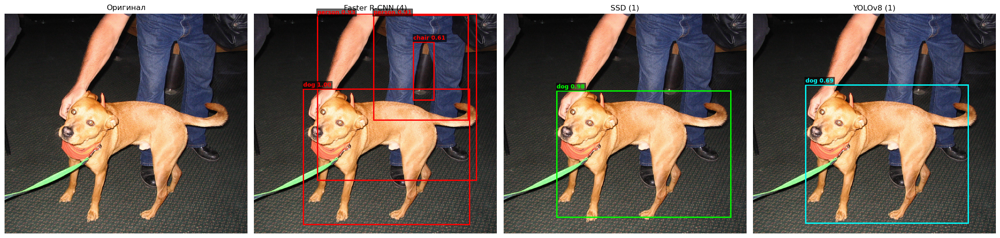

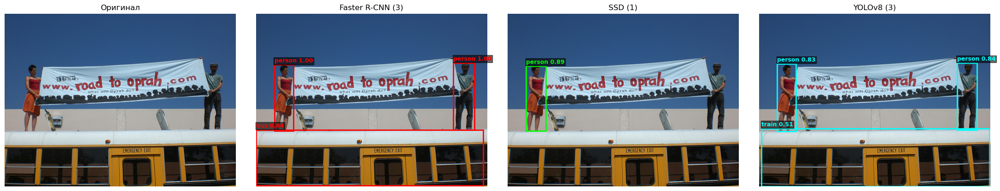

In [14]:
def draw_results(ax, img, results, title, color='red'):
    ax.imshow(img)
    for r in results:
        xmin, ymin, xmax, ymax = r['bbox']
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            xmin, max(ymin - 5, 0),
            f"{r['label']} {r['score']:.2f}",
            color=color, fontsize=9, weight='bold',
            bbox=dict(facecolor='black', alpha=0.6, pad=1)
        )
    ax.set_title(title, fontsize=12)
    ax.axis('off')

def compare_models(img_id):
    img_path = os.path.join(JPEG_DIR, img_id + '.jpg')
    img = Image.open(img_path).convert('RGB')

    res_f = run_faster_rcnn(img)
    res_s = run_ssd(img)
    res_y = run_yolo(img)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(img); axes[0].set_title('Оригинал'); axes[0].axis('off')
    draw_results(axes[1], img, res_f, f'Faster R-CNN ({len(res_f)})', color='red')
    draw_results(axes[2], img, res_s, f'SSD ({len(res_s)})', color='lime')
    draw_results(axes[3], img, res_y, f'YOLOv8 ({len(res_y)})', color='cyan')
    plt.tight_layout()
    plt.show()

# Попробуем на паре изображений
compare_models(sample_ids[0])
compare_models(sample_ids[1])

YOLO загружен: yolov8m


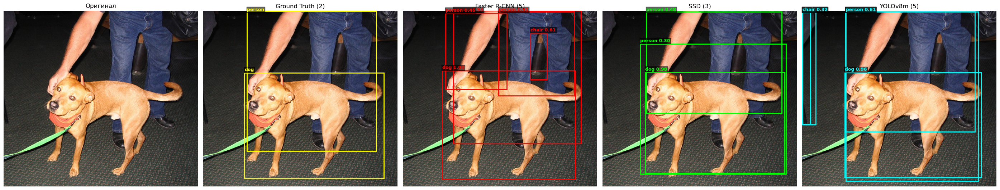

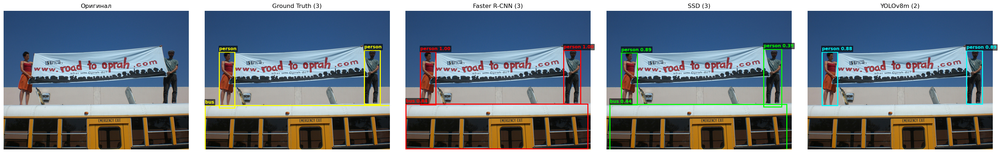

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# --- 1. (Один раз) переключаем YOLO на medium-версию ---
from ultralytics import YOLO
yolo = YOLO("yolov8m.pt")
yolo_categories = yolo.names
print("YOLO загружен:", "yolov8m")

# --- 2. Отрисовка Ground Truth ---
def draw_gt(ax, img_id, img):
    ann = parse_annotation(os.path.join(ANNOT_DIR, img_id + '.xml'))
    ax.imshow(img)
    for obj in ann['objects']:
        xmin, ymin, xmax, ymax = obj['bbox']
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='yellow', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xmin, max(ymin - 5, 0), obj['name'],
                color='yellow', fontsize=9, weight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    ax.set_title(f'Ground Truth ({len(ann["objects"])})', fontsize=12)
    ax.axis('off')

# --- 3. Отрисовка предсказаний ---
def draw_results(ax, img, results, title, color='red'):
    ax.imshow(img)
    for r in results:
        xmin, ymin, xmax, ymax = r['bbox']
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xmin, max(ymin - 5, 0),
                f"{r['label']} {r['score']:.2f}",
                color=color, fontsize=9, weight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# --- 4. Сравнение трёх моделей на одном изображении ---
def compare_models(img_id, score_thresh=0.25):
    img = Image.open(os.path.join(JPEG_DIR, img_id + '.jpg')).convert('RGB')

    res_f = run_faster_rcnn(img, score_thresh)
    res_s = run_ssd(img, score_thresh)
    res_y = run_yolo(img, score_thresh)

    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    axes[0].imshow(img); axes[0].set_title('Оригинал'); axes[0].axis('off')
    draw_gt(axes[1], img_id, img)
    draw_results(axes[2], img, res_f, f'Faster R-CNN ({len(res_f)})', color='red')
    draw_results(axes[3], img, res_s, f'SSD ({len(res_s)})', color='lime')
    draw_results(axes[4], img, res_y, f'YOLOv8m ({len(res_y)})', color='cyan')
    plt.tight_layout()
    plt.show()

# --- 5. Запускаем на паре изображений ---
compare_models(sample_ids[0])
compare_models(sample_ids[1])

Изменение освещения

In [16]:
import os, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchmetrics.detection import MeanAveragePrecision
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Список классов VOC с индексами ---
VOC_LIST = ['aeroplane','bicycle','bird','boat','bottle','bus','car','cat','chair',
            'cow','diningtable','dog','horse','motorbike','person','pottedplant',
            'sheep','sofa','train','tvmonitor']
VOC_TO_IDX = {name: i for i, name in enumerate(VOC_LIST)}

# --- Выборка из val ---
with open(os.path.join(IMSETS_DIR, 'val.txt')) as f:
    val_ids = [line.strip().split()[0] for line in f if line.strip()]

random.seed(42)
N_IMAGES = 150
subset_ids = random.sample(val_ids, N_IMAGES)
print(f"Выбрано {len(subset_ids)} изображений из val")

# --- Гамма-коррекция ---
def apply_gamma(img, gamma):
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.power(arr, gamma)
    arr = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

CONDITIONS = {'dark': 2.2, 'normal': 1.0, 'bright': 0.45}

# --- Ground truth в формате torchmetrics ---
def get_gt(img_id):
    ann = parse_annotation(os.path.join(ANNOT_DIR, img_id + '.xml'))
    boxes, labels = [], []
    for obj in ann['objects']:
        if obj['difficult']:
            continue
        idx = VOC_TO_IDX.get(obj['name'])
        if idx is None:
            continue
        boxes.append(obj['bbox']); labels.append(idx)
    if not boxes:
        return None
    return {
        'boxes': torch.tensor(boxes, dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.int64),
    }

Выбрано 150 изображений из val


In [17]:
def run_model(model_name, img):
    if model_name == 'faster':
        res = run_faster_rcnn(img, score_thresh=0.05)
    elif model_name == 'ssd':
        res = run_ssd(img, score_thresh=0.05)
    elif model_name == 'yolo':
        res = run_yolo(img, score_thresh=0.05)

    boxes, scores, labels = [], [], []
    for r in res:
        idx = VOC_TO_IDX.get(r['label'])
        if idx is None:
            continue
        boxes.append(r['bbox']); scores.append(r['score']); labels.append(idx)

    if not boxes:
        return {
            'boxes':  torch.zeros((0, 4), dtype=torch.float32),
            'scores': torch.zeros((0,),   dtype=torch.float32),
            'labels': torch.zeros((0,),   dtype=torch.int64),
        }
    return {
        'boxes':  torch.tensor(boxes,  dtype=torch.float32),
        'scores': torch.tensor(scores, dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.int64),
    }

MODELS = ['faster', 'ssd', 'yolo']
results = {m: {c: {'preds': [], 'targets': []} for c in CONDITIONS} for m in MODELS}

for img_id in tqdm(subset_ids, desc='Прогон'):
    gt = get_gt(img_id)
    if gt is None:
        continue
    base_img = Image.open(os.path.join(JPEG_DIR, img_id + '.jpg')).convert('RGB')

    for cond, gamma in CONDITIONS.items():
        img = apply_gamma(base_img, gamma)
        for m in MODELS:
            pred = run_model(m, img)
            results[m][cond]['preds'].append(pred)
            results[m][cond]['targets'].append(gt)

Прогон: 100%|██████████| 150/150 [07:30<00:00,  3.00s/it]


In [29]:
import torch
from torchmetrics.detection import MeanAveragePrecision

def limit_dets(pred, max_det=100):
    """Оставляем не более max_det детекций с наибольшим score — стандарт COCO."""
    n = len(pred['scores'])
    if n <= max_det:
        return pred
    topk = torch.topk(pred['scores'], max_det).indices
    return {
        'boxes':  pred['boxes'][topk],
        'scores': pred['scores'][topk],
        'labels': pred['labels'][topk],
    }

def compute_map(preds, targets):
    # обрезаем каждое предсказание
    preds_limited = [limit_dets(p) for p in preds]

    metric = MeanAveragePrecision(
        box_format='xyxy',
        iou_type='bbox',
        class_metrics=False,
        # max_detection_thresholds НЕ трогаем — оставляем дефолт [1, 10, 100]
    )
    metric.warn_on_many_detections = False   # глушим warning, раз мы уже сами обрезали
    metric.update(preds_limited, targets)
    res = metric.compute()
    return float(res['map']), float(res['map_50'])

table = {}
for m in MODELS:
    table[m] = {}
    for cond in CONDITIONS:
        mAP, mAP50 = compute_map(results[m][cond]['preds'], results[m][cond]['targets'])
        table[m][cond] = (mAP, mAP50)
        print(f"{m:7s} | {cond:6s} | mAP={mAP:.4f} | mAP@0.5={mAP50:.4f}")

faster  | dark   | mAP=0.5010 | mAP@0.5=0.7647
faster  | normal | mAP=0.5384 | mAP@0.5=0.7869
faster  | bright | mAP=0.5120 | mAP@0.5=0.7604
ssd     | dark   | mAP=0.4928 | mAP@0.5=0.7383
ssd     | normal | mAP=0.5010 | mAP@0.5=0.7346
ssd     | bright | mAP=0.4969 | mAP@0.5=0.7465
yolo    | dark   | mAP=0.6880 | mAP@0.5=0.8224
yolo    | normal | mAP=0.7162 | mAP@0.5=0.8461
yolo    | bright | mAP=0.7144 | mAP@0.5=0.8459


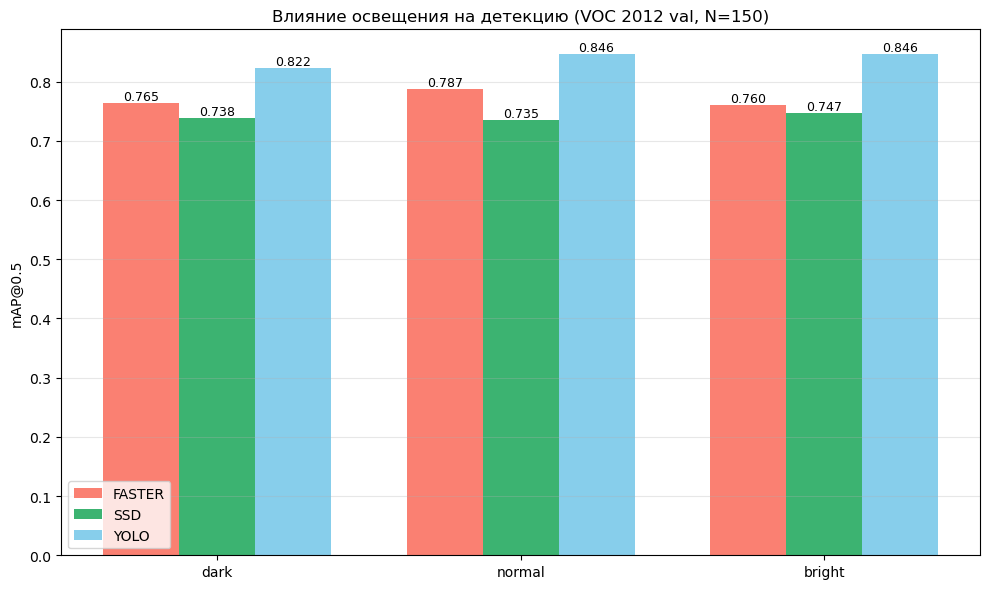

In [30]:
import numpy as np

conditions = list(CONDITIONS.keys())
x = np.arange(len(conditions))
width = 0.25
colors = {'faster': 'salmon', 'ssd': 'mediumseagreen', 'yolo': 'skyblue'}

fig, ax = plt.subplots(figsize=(10, 6))
for i, m in enumerate(MODELS):
    vals = [table[m][c][1] for c in conditions]
    bars = ax.bar(x + i*width, vals, width, label=m.upper(), color=colors[m])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha='center', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(conditions)
ax.set_ylabel('mAP@0.5')
ax.set_title('Влияние освещения на детекцию (VOC 2012 val, N=150)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

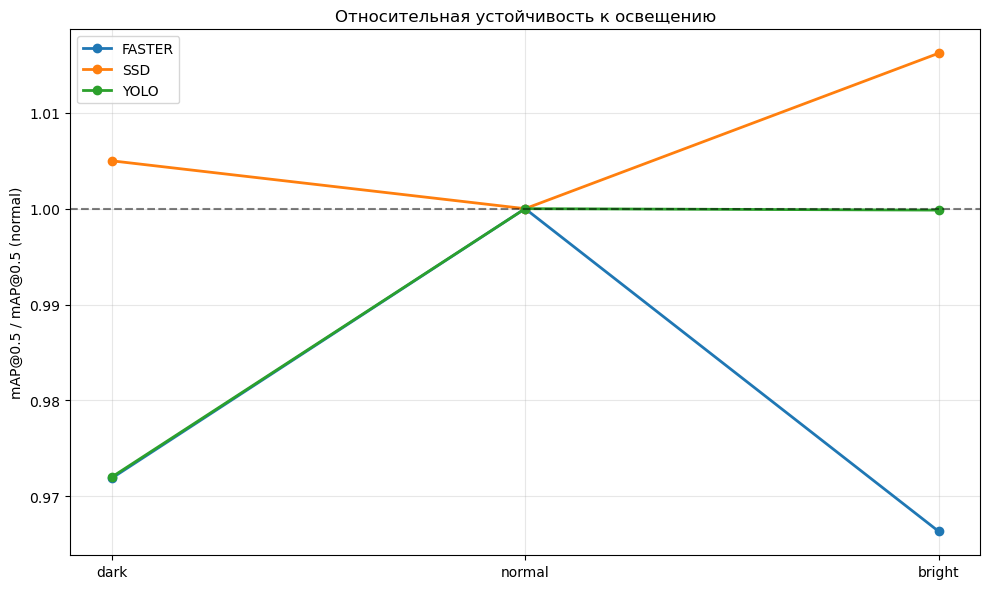

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODELS:
    base = table[m]['normal'][1]
    rel = [table[m][c][1] / base for c in conditions]
    ax.plot(conditions, rel, marker='o', label=m.upper(), linewidth=2)

ax.axhline(1.0, color='black', linestyle='--', alpha=0.5)
ax.set_ylabel('mAP@0.5 / mAP@0.5 (normal)')
ax.set_title('Относительная устойчивость к освещению')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Детекция на видео

In [21]:
import os, cv2, time

# --- Посмотрим, какие видео есть в папке ---
for f in os.listdir('.'):
    if f.lower().endswith(('.mp4', '.mov', '.avi', '.mkv', '.webm')):
        print(f)

VIDEO_PATH = "Crazy GTA-Like High Speed Chase _ LX News.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
fps_in    = cap.get(cv2.CAP_PROP_FPS)
n_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h         = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration  = n_frames / fps_in if fps_in else 0

print(f"FPS: {fps_in:.2f}")
print(f"Кадров: {n_frames}, длительность: {duration:.2f} сек")
print(f"Разрешение: {w}x{h}")
cap.release()

Crazy GTA-Like High Speed Chase _ LX News.mp4
From 2003_ Colin Powell Addresses United Nations Security Council On Iraq.mp4
output_faster.mp4
output_ssd.mp4
output_yolo.mp4
FPS: 30.00
Кадров: 1566, длительность: 52.20 сек
Разрешение: 480x854


In [22]:
def process_video(model_name, video_path, output_path,
                  stride=3, max_frames=150, score_thresh=0.35):
    """
    model_name: 'faster' | 'ssd' | 'yolo'
    """
    cap = cv2.VideoCapture(video_path)
    fps_in = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps_in / stride, (w, h))

    frame_idx = 0
    processed = 0
    total_time = 0.0
    all_dets = []

    while cap.isOpened() and processed < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % stride != 0:
            frame_idx += 1
            continue

        # OpenCV даёт BGR -> конвертируем в RGB для PIL/моделей
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)

        t0 = time.perf_counter()
        if model_name == 'faster':
            dets = run_faster_rcnn(pil_img, score_thresh)
        elif model_name == 'ssd':
            dets = run_ssd(pil_img, score_thresh)
        elif model_name == 'yolo':
            dets = run_yolo(pil_img, score_thresh)
        total_time += time.perf_counter() - t0

        all_dets.append(len(dets))

        # Рисуем боксы на BGR-кадре
        for d in dets:
            x1, y1, x2, y2 = map(int, d['bbox'])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"{d['label']} {d['score']:.2f}"
            cv2.putText(frame, label, (x1, max(y1 - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        out.write(frame)
        processed += 1
        frame_idx += 1

    cap.release()
    out.release()

    avg_dets = sum(all_dets) / len(all_dets) if all_dets else 0
    avg_fps = processed / total_time if total_time > 0 else 0

    return {
        'frames_processed': processed,
        'total_inference_time_s': round(total_time, 2),
        'avg_fps': round(avg_fps, 2),
        'avg_detections_per_frame': round(avg_dets, 2),
    }

In [23]:
models_to_run = ['faster', 'ssd', 'yolo']
video_stats = {}

for m in models_to_run:
    print(f"\n=== Обработка видео моделью {m.upper()} ===")
    stats = process_video(
        model_name=m,
        video_path=VIDEO_PATH,
        output_path=f"output_{m}.mp4",
        stride=3,
        max_frames=150,
        score_thresh=0.35,
    )
    video_stats[m] = stats
    print(stats)


=== Обработка видео моделью FASTER ===
{'frames_processed': 150, 'total_inference_time_s': 249.36, 'avg_fps': 0.6, 'avg_detections_per_frame': 3.07}

=== Обработка видео моделью SSD ===
{'frames_processed': 150, 'total_inference_time_s': 26.32, 'avg_fps': 5.7, 'avg_detections_per_frame': 1.29}

=== Обработка видео моделью YOLO ===
{'frames_processed': 150, 'total_inference_time_s': 30.89, 'avg_fps': 4.86, 'avg_detections_per_frame': 2.11}


        frames_processed  avg_fps  total_inference_time_s  \
model                                                       
faster             150.0     0.60                  249.36   
ssd                150.0     5.70                   26.32   
yolo               150.0     4.86                   30.89   

        avg_detections_per_frame  
model                             
faster                      3.07  
ssd                         1.29  
yolo                        2.11  


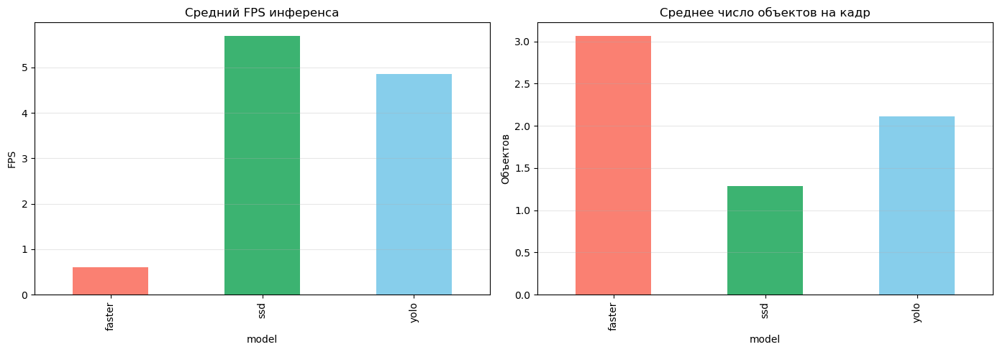

In [24]:
import pandas as pd

df = pd.DataFrame(video_stats).T
df.index.name = 'model'
df = df[['frames_processed', 'avg_fps', 'total_inference_time_s',
         'avg_detections_per_frame']]
print(df)

# Bar chart по FPS
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['avg_fps'].plot(kind='bar', ax=ax[0], color=['salmon','mediumseagreen','skyblue'])
ax[0].set_title('Средний FPS инференса')
ax[0].set_ylabel('FPS')
ax[0].grid(axis='y', alpha=0.3)

df['avg_detections_per_frame'].plot(kind='bar', ax=ax[1], color=['salmon','mediumseagreen','skyblue'])
ax[1].set_title('Среднее число объектов на кадр')
ax[1].set_ylabel('Объектов')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path, width=480):
    mp4 = open(path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width={width} controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

show_video("output_faster.mp4")
show_video("output_yolo.mp4")
show_video("output_ssd.mp4")

Подсчёт объектов

In [32]:
from collections import Counter

# Посчитаем число GT-объектов (без difficult) для каждого изображения
def count_gt_objects(img_id):
    ann = parse_annotation(os.path.join(ANNOT_DIR, img_id + '.xml'))
    return sum(1 for o in ann['objects'] if not o['difficult'])

density_map = {img_id: count_gt_objects(img_id) for img_id in subset_ids}

# Разбиваем на группы
groups = {'sparse': [], 'medium': [], 'crowded': []}
for img_id, n in density_map.items():
    if n <= 2:
        groups['sparse'].append(img_id)
    elif n <= 5:
        groups['medium'].append(img_id)
    else:
        groups['crowded'].append(img_id)

for g, ids in groups.items():
    print(f"{g:8s}: {len(ids)} изображений")

sparse  : 112 изображений
medium  : 26 изображений
crowded : 12 изображений


In [33]:
# Перезапускаем сбор — уже только для normal, но с сохранением img_id
results_by_id = {m: {} for m in MODELS}

for img_id in tqdm(subset_ids, desc='Сбор для групп'):
    gt = get_gt(img_id)
    if gt is None:
        continue
    img = Image.open(os.path.join(JPEG_DIR, img_id + '.jpg')).convert('RGB')
    img = apply_gamma(img, 1.0)   # только normal — быстрее

    for m in MODELS:
        pred = run_model(m, img)
        results_by_id[m][img_id] = {'pred': pred, 'target': gt}

Сбор для групп: 100%|██████████| 150/150 [02:21<00:00,  1.06it/s]


In [34]:
def compute_metrics(preds, targets):
    metric = MeanAveragePrecision(
        box_format='xyxy',
        iou_type='bbox',
        class_metrics=False,
    )
    metric.warn_on_many_detections = False
    preds_limited = [limit_dets(p) for p in preds]
    metric.update(preds_limited, targets)
    res = metric.compute()
    return {
        'mAP':      float(res['map']),
        'mAP_50':   float(res['map_50']),
        'mar_100':  float(res['mar_100']),   # mean average recall — покажет пропуски
    }

group_table = {}
for m in MODELS:
    group_table[m] = {}
    for g, ids in groups.items():
        preds   = [results_by_id[m][i]['pred']   for i in ids if i in results_by_id[m]]
        targets = [results_by_id[m][i]['target'] for i in ids if i in results_by_id[m]]
        if not preds:
            continue
        metrics = compute_metrics(preds, targets)
        group_table[m][g] = metrics
        print(f"{m:7s} | {g:8s} | mAP={metrics['mAP']:.4f} | "
              f"mAP@0.5={metrics['mAP_50']:.4f} | AR@100={metrics['mar_100']:.4f}")

faster  | sparse   | mAP=0.5789 | mAP@0.5=0.7948 | AR@100=0.7269
faster  | medium   | mAP=0.6062 | mAP@0.5=0.8804 | AR@100=0.6693
faster  | crowded  | mAP=0.4371 | mAP@0.5=0.7014 | AR@100=0.5887
ssd     | sparse   | mAP=0.5394 | mAP@0.5=0.7379 | AR@100=0.6713
ssd     | medium   | mAP=0.5186 | mAP@0.5=0.8241 | AR@100=0.6195
ssd     | crowded  | mAP=0.4023 | mAP@0.5=0.6462 | AR@100=0.5234
yolo    | sparse   | mAP=0.7186 | mAP@0.5=0.8269 | AR@100=0.7858
yolo    | medium   | mAP=0.7536 | mAP@0.5=0.9170 | AR@100=0.7899
yolo    | crowded  | mAP=0.6194 | mAP@0.5=0.7498 | AR@100=0.7758


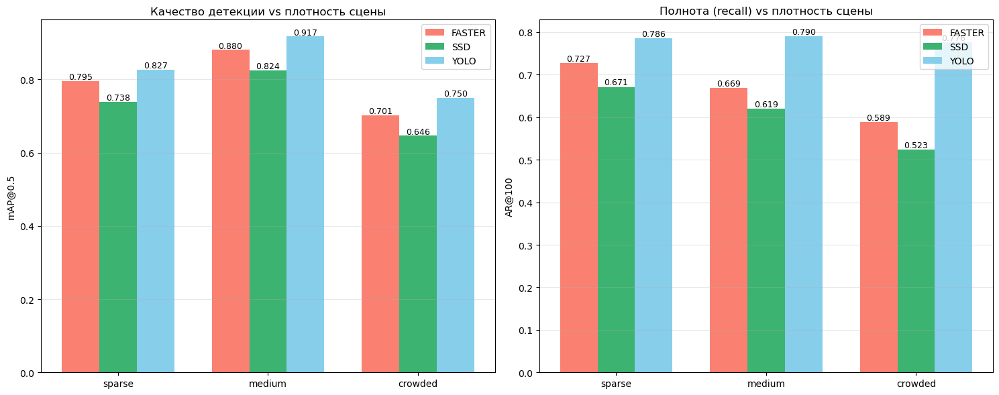

In [35]:
import numpy as np

group_names = ['sparse', 'medium', 'crowded']
x = np.arange(len(group_names))
width = 0.25
colors = {'faster': 'salmon', 'ssd': 'mediumseagreen', 'yolo': 'skyblue'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# mAP@0.5
for i, m in enumerate(MODELS):
    vals = [group_table[m].get(g, {}).get('mAP_50', 0) for g in group_names]
    bars = axes[0].bar(x + i*width, vals, width, label=m.upper(), color=colors[m])
    for b, v in zip(bars, vals):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                     ha='center', fontsize=9)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(group_names)
axes[0].set_ylabel('mAP@0.5')
axes[0].set_title('Качество детекции vs плотность сцены')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# AR@100 (recall)
for i, m in enumerate(MODELS):
    vals = [group_table[m].get(g, {}).get('mar_100', 0) for g in group_names]
    bars = axes[1].bar(x + i*width, vals, width, label=m.upper(), color=colors[m])
    for b, v in zip(bars, vals):
        axes[1].text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                     ha='center', fontsize=9)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(group_names)
axes[1].set_ylabel('AR@100')
axes[1].set_title('Полнота (recall) vs плотность сцены')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Размер объектов

In [37]:
def compute_metrics_by_size(preds, targets):
    metric = MeanAveragePrecision(
        box_format='xyxy',
        iou_type='bbox',
        class_metrics=False,
    )
    metric.warn_on_many_detections = False
    preds_limited = [limit_dets(p) for p in preds]
    metric.update(preds_limited, targets)
    res = metric.compute()
    return {
        'mAP':           float(res['map']),
        'mAP_small':     float(res['map_small']),
        'mAP_medium':    float(res['map_medium']),
        'mAP_large':     float(res['map_large']),
        'mAP_50':        float(res['map_50']),
        # ✅ правильные ключи для recall по размерам:
        'mar_small':     float(res['mar_small']),
        'mar_medium':    float(res['mar_medium']),
        'mar_large':     float(res['mar_large']),
        # глобальный recall при 100 детекциях (без разбивки по размеру):
        'mar_100':       float(res['mar_100']),
    }

size_table = {}
for m in MODELS:
    preds   = [results_by_id[m][i]['pred']   for i in subset_ids if i in results_by_id[m]]
    targets = [results_by_id[m][i]['target'] for i in subset_ids if i in results_by_id[m]]
    metrics = compute_metrics_by_size(preds, targets)
    size_table[m] = metrics
    print(f"{m:7s} | small={metrics['mAP_small']:.4f} | "
          f"medium={metrics['mAP_medium']:.4f} | large={metrics['mAP_large']:.4f}")

faster  | small=0.3929 | medium=0.5061 | large=0.6072
ssd     | small=0.2913 | medium=0.3908 | large=0.5783
yolo    | small=0.3894 | medium=0.6383 | large=0.7622


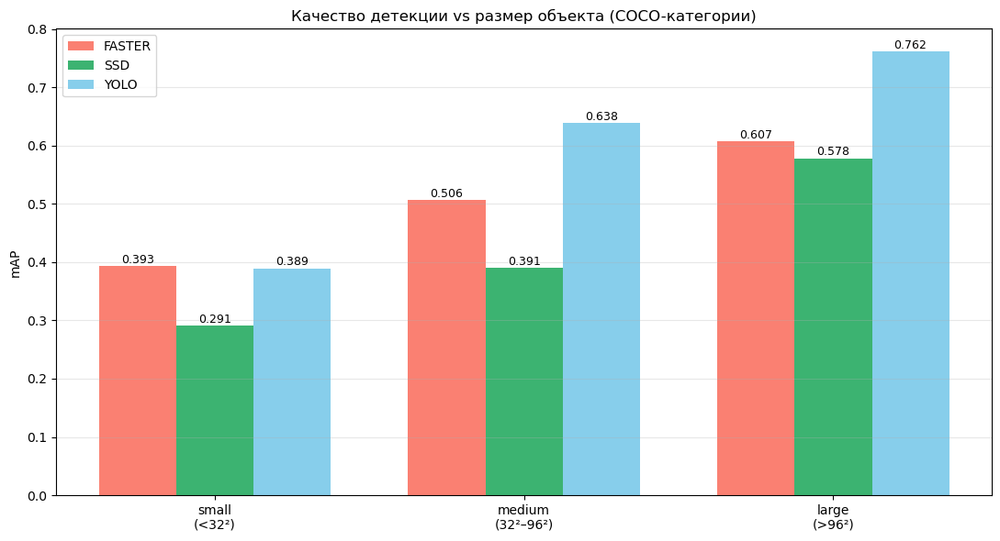

In [38]:
import numpy as np

size_names = ['mAP_small', 'mAP_medium', 'mAP_large']
labels     = ['small\n(<32²)', 'medium\n(32²–96²)', 'large\n(>96²)']
x = np.arange(len(size_names))
width = 0.25
colors = {'faster': 'salmon', 'ssd': 'mediumseagreen', 'yolo': 'skyblue'}

fig, ax = plt.subplots(figsize=(11, 6))
for i, m in enumerate(MODELS):
    vals = [size_table[m][k] for k in size_names]
    bars = ax.bar(x + i*width, vals, width, label=m.upper(), color=colors[m])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha='center', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylabel('mAP')
ax.set_title('Качество детекции vs размер объекта (COCO-категории)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

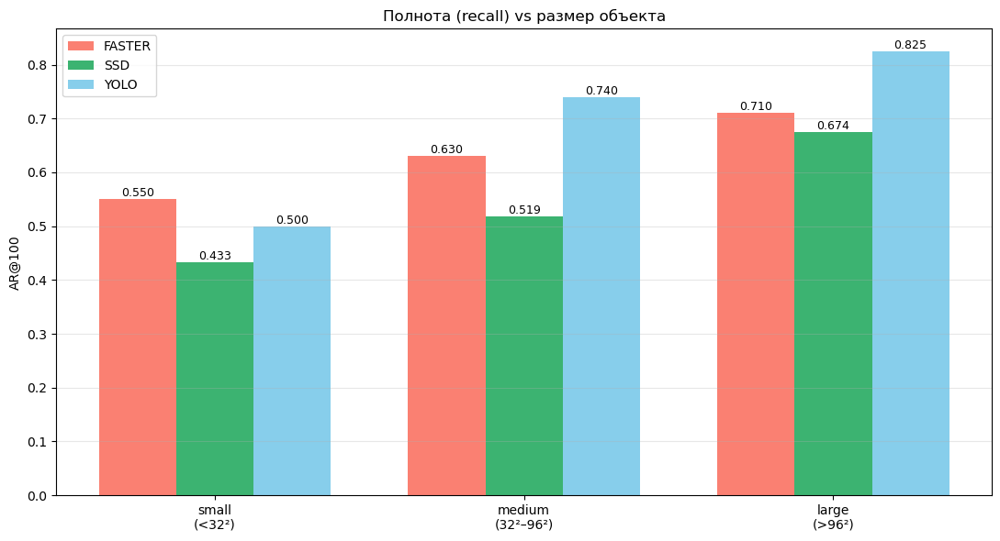

In [39]:
recall_names = ['mar_small', 'mar_medium', 'mar_large']

fig, ax = plt.subplots(figsize=(11, 6))
for i, m in enumerate(MODELS):
    vals = [size_table[m][k] for k in recall_names]
    bars = ax.bar(x + i*width, vals, width, label=m.upper(), color=colors[m])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha='center', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylabel('AR@100')
ax.set_title('Полнота (recall) vs размер объекта')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Снова видео

In [40]:
import os, cv2, time, json
import numpy as np
from PIL import Image
from tqdm import tqdm

def process_video_with_stats(model_name, video_path, output_path,
                             stride=3, max_frames=300, score_thresh=0.35):
    cap = cv2.VideoCapture(video_path)
    fps_in = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps_in / stride, (w, h))

    frame_idx = 0
    processed = 0
    total_time = 0.0
    per_frame = []  # список словарей: frame_num, brightness, n_dets, labels

    while cap.isOpened() and processed < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % stride != 0:
            frame_idx += 1
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)

        # яркость кадра: среднее по каналу V в HSV
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        brightness = float(hsv[:, :, 2].mean())

        t0 = time.perf_counter()
        if model_name == 'faster':
            dets = run_faster_rcnn(pil_img, score_thresh)
        elif model_name == 'ssd':
            dets = run_ssd(pil_img, score_thresh)
        elif model_name == 'yolo':
            dets = run_yolo(pil_img, score_thresh)
        total_time += time.perf_counter() - t0

        # рисуем
        labels_here = []
        for d in dets:
            x1, y1, x2, y2 = map(int, d['bbox'])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{d['label']} {d['score']:.2f}",
                        (x1, max(y1 - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            labels_here.append(d['label'])

        out.write(frame)

        per_frame.append({
            'frame': processed,
            'orig_frame': frame_idx,
            'brightness': round(brightness, 2),
            'n_dets': len(dets),
            'labels': labels_here,
        })

        processed += 1
        frame_idx += 1

    cap.release()
    out.release()

    avg_fps = processed / total_time if total_time > 0 else 0
    return {
        'frames_processed': processed,
        'total_inference_time_s': round(total_time, 2),
        'avg_fps': round(avg_fps, 2),
        'avg_dets_per_frame': round(np.mean([p['n_dets'] for p in per_frame]), 2),
        'per_frame': per_frame,
    }

In [41]:
VIDEO_PATH = "Crazy GTA-Like High Speed Chase _ LX News.mp4"

video_stats = {}
for m in ['faster', 'ssd', 'yolo']:
    print(f"\n=== {m.upper()} ===")
    stats = process_video_with_stats(
        model_name=m,
        video_path=VIDEO_PATH,
        output_path=f"output_{m}.mp4",
        stride=3,           # каждый 3-й кадр
        max_frames=300,     # ограничим для скорости
        score_thresh=0.35,
    )
    video_stats[m] = stats
    print(f"  frames: {stats['frames_processed']}")
    print(f"  FPS: {stats['avg_fps']}")
    print(f"  avg dets/frame: {stats['avg_dets_per_frame']}")


=== FASTER ===
  frames: 300
  FPS: 0.59
  avg dets/frame: 3.0

=== SSD ===
  frames: 300
  FPS: 5.5
  avg dets/frame: 1.18

=== YOLO ===
  frames: 300
  FPS: 4.87
  avg dets/frame: 2.11


         FPS  Время, с  Детекций/кадр  Кадров обработано
faster  0.59    510.48           3.00              300.0
ssd     5.50     54.51           1.18              300.0
yolo    4.87     61.61           2.11              300.0


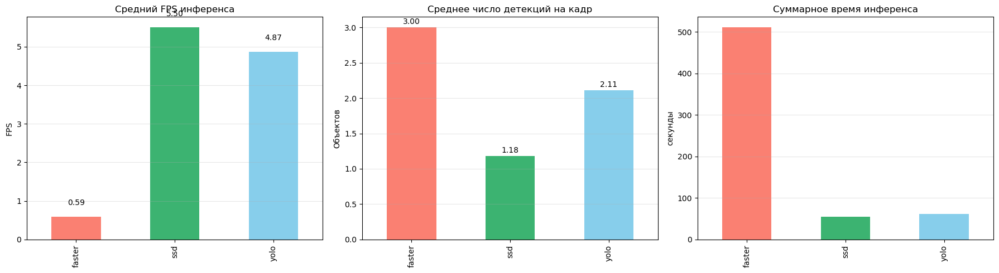

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    m: {
        'FPS': s['avg_fps'],
        'Время, с': s['total_inference_time_s'],
        'Детекций/кадр': s['avg_dets_per_frame'],
        'Кадров обработано': s['frames_processed'],
    } for m, s in video_stats.items()
}).T

print(df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'faster': 'salmon', 'ssd': 'mediumseagreen', 'yolo': 'skyblue'}

# FPS
df['FPS'].plot(kind='bar', ax=axes[0], color=[colors[i] for i in df.index])
axes[0].set_title('Средний FPS инференса')
axes[0].set_ylabel('FPS'); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df['FPS']):
    axes[0].text(i, v + 0.3, f"{v:.2f}", ha='center')

# Детекций на кадр
df['Детекций/кадр'].plot(kind='bar', ax=axes[1], color=[colors[i] for i in df.index])
axes[1].set_title('Среднее число детекций на кадр')
axes[1].set_ylabel('Объектов'); axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df['Детекций/кадр']):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha='center')

# Время
df['Время, с'].plot(kind='bar', ax=axes[2], color=[colors[i] for i in df.index])
axes[2].set_title('Суммарное время инференса')
axes[2].set_ylabel('секунды'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
def analyze_brightness_segments(per_frame, n_segments=3):
    b = np.array([p['brightness'] for p in per_frame])
    qs = np.quantile(b, np.linspace(0, 1, n_segments + 1))
    segments = {'dark': [], 'normal': [], 'bright': []}
    for p in per_frame:
        val = p['brightness']
        if val <= qs[1]:
            segments['dark'].append(p)
        elif val <= qs[2]:
            segments['normal'].append(p)
        else:
            segments['bright'].append(p)
    return {k: {
        'n_frames': len(v),
        'avg_dets': round(np.mean([p['n_dets'] for p in v]), 2) if v else 0,
        'avg_brightness': round(np.mean([p['brightness'] for p in v]), 1) if v else 0,
    } for k, v in segments.items()}

brightness_table = {m: analyze_brightness_segments(s['per_frame'])
                    for m, s in video_stats.items()}

for m, segs in brightness_table.items():
    print(f"\n{m.upper()}:")
    for name, vals in segs.items():
        print(f"  {name:6s} | кадров={vals['n_frames']:3d} | "
              f"яркость={vals['avg_brightness']:5.1f} | "
              f"детекций/кадр={vals['avg_dets']:.2f}")


FASTER:
  dark   | кадров=100 | яркость= 85.0 | детекций/кадр=2.94
  normal | кадров=101 | яркость=101.9 | детекций/кадр=3.27
  bright | кадров= 99 | яркость=117.4 | детекций/кадр=2.78

SSD:
  dark   | кадров=100 | яркость= 85.0 | детекций/кадр=1.31
  normal | кадров=101 | яркость=101.9 | детекций/кадр=0.92
  bright | кадров= 99 | яркость=117.4 | детекций/кадр=1.30

YOLO:
  dark   | кадров=100 | яркость= 85.0 | детекций/кадр=2.10
  normal | кадров=101 | яркость=101.9 | детекций/кадр=2.02
  bright | кадров= 99 | яркость=117.4 | детекций/кадр=2.20


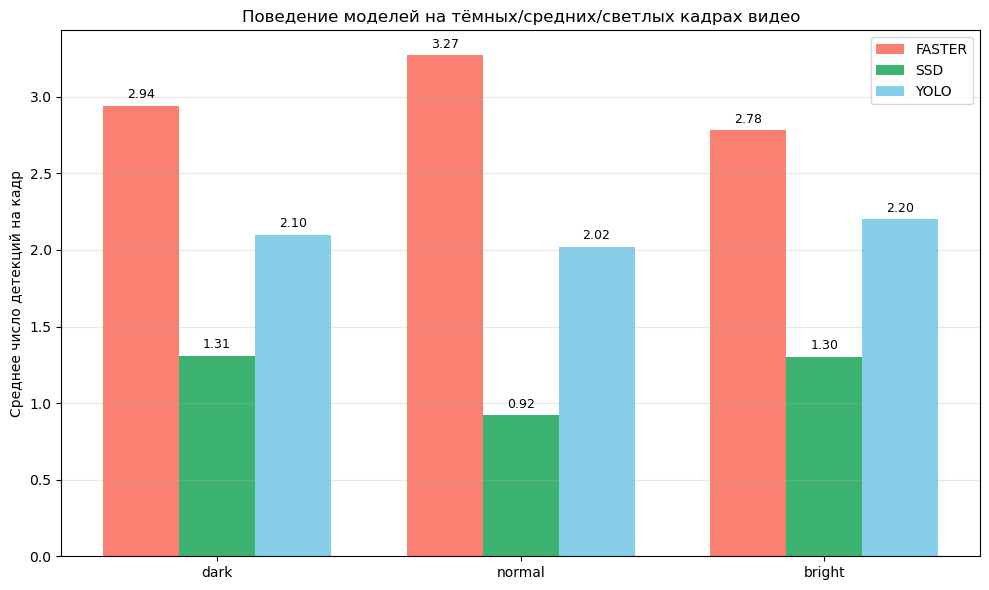

In [44]:
seg_names = ['dark', 'normal', 'bright']
x = np.arange(len(seg_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, m in enumerate(['faster', 'ssd', 'yolo']):
    vals = [brightness_table[m][s]['avg_dets'] for s in seg_names]
    bars = ax.bar(x + i*width, vals, width, label=m.upper(), color=colors[m])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}",
                ha='center', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(seg_names)
ax.set_ylabel('Среднее число детекций на кадр')
ax.set_title('Поведение моделей на тёмных/средних/светлых кадрах видео')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

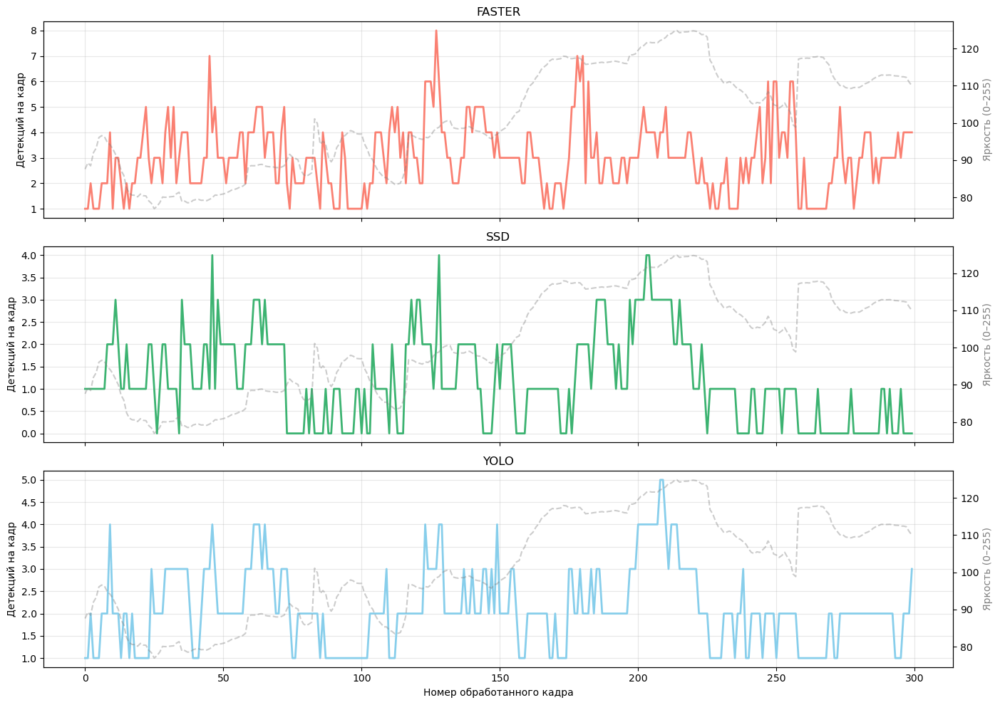

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, m in zip(axes, ['faster', 'ssd', 'yolo']):
    frames = [p['frame'] for p in video_stats[m]['per_frame']]
    dets   = [p['n_dets'] for p in video_stats[m]['per_frame']]
    br     = [p['brightness'] for p in video_stats[m]['per_frame']]

    ax.plot(frames, dets, label='Число детекций', color=colors[m], linewidth=2)
    ax2 = ax.twinx()
    ax2.plot(frames, br, label='Яркость', color='gray', alpha=0.4, linestyle='--')
    ax2.set_ylabel('Яркость (0–255)', color='gray')
    ax.set_ylabel('Детекций на кадр')
    ax.set_title(m.upper())
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Номер обработанного кадра')
plt.tight_layout()
plt.show()

In [46]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path, width=480):
    if not os.path.exists(path):
        print("Нет файла:", path); return
    mp4 = open(path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f'<video width={width} controls>'
                f'<source src="{data_url}" type="video/mp4"></video>')

show_video("output_faster.mp4")
show_video("output_ssd.mp4")
show_video("output_yolo.mp4")